In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn import model_selection
from sklearn import metrics
from scipy import stats

df_boston = pd.read_csv("boston.csv")
print(df_boston)

        CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0    0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1    0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2    0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3    0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4    0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...    ...   
501  0.06263   0.0  11.93   0.0  0.573  6.593  69.1  2.4786  1.0  273.0   
502  0.04527   0.0  11.93   0.0  0.573  6.120  76.7  2.2875  1.0  273.0   
503  0.06076   0.0  11.93   0.0  0.573  6.976  91.0  2.1675  1.0  273.0   
504  0.10959   0.0  11.93   0.0  0.573  6.794  89.3  2.3889  1.0  273.0   
505  0.04741   0.0  11.93   0.0  0.573  6.030  80.8  2.5050  1.0  273.0   

     PTRATIO       B  LSTAT  MEDV  
0       15.3  396.90   4.98  24.0  
1       17.8  396.90   9.14

In [3]:
# CRIM → 범죄율
# ZN → 대형 주거지 비율
# INDUS → 비소매 상업 지역 비율
# CHAS → 찰스강 더미 변수
# NOX → 일산화질소 농도
# RM → 주택당 평균 방 개수
# AGE → 오래된 주택 비율
# DIS → 직주 근접도
# RAD → 방사형 고속도로 접근성 지수
# TAX → 재산세율
# PTRATIO → 학생-교사 비율
# B → 흑인 인구 비율 지수
# LSTAT → 하위 계층 비율
# MEDV → 주택 가격 중앙값

In [4]:
shapiro_test = stats.shapiro(df_boston)
print(shapiro_test) # pvalue=np.float64(7.348722154426317e-88)

ShapiroResult(statistic=np.float64(0.5189043882319008), pvalue=np.float64(7.348722154426317e-88))


c:\Users\user\.conda\envs\env_ds\Lib\site-packages\scipy\stats\_axis_nan_policy.py:592: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 7084.
  res = hypotest_fun_out(*samples, **kwds)


In [5]:
df_boston.info()
df_boston.shape

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


(506, 14)

In [6]:
print(df_boston.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.613524   11.363636   11.136779    0.069170    0.554695    6.284634   
std      8.601545   23.322453    6.860353    0.253994    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.082045    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.256510    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      3.677083   12.500000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.574901    3.795043    9.549407  408.237154   18.455534  356.674032   
std     28.148861    2.1057

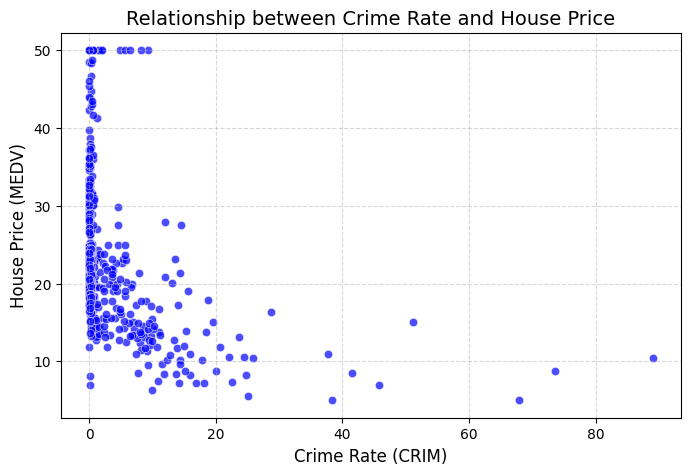

In [7]:
# df_boston["CRIM"].value_counts()

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="CRIM", 
    y="MEDV", 
    data=df_boston, 
    alpha=0.7,      
    color="blue"    
)

plt.title("Relationship between Crime Rate and House Price", fontsize=14)
plt.xlabel("Crime Rate (CRIM)", fontsize=12)
plt.ylabel("House Price (MEDV)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

# 분석

# CRIM(범죄율)이 낮은 지역에 산점도가 밀접해있음.
# CRIM(범죄율)이 높을수록 MEDV(주택 가격 중앙값)은 떨어져있는 흐름을 보이고 있다.
# CRIM(범죄율)과 MEDV(주택 가격)은 밀접한 관련이 있다고 볼 수 있다.

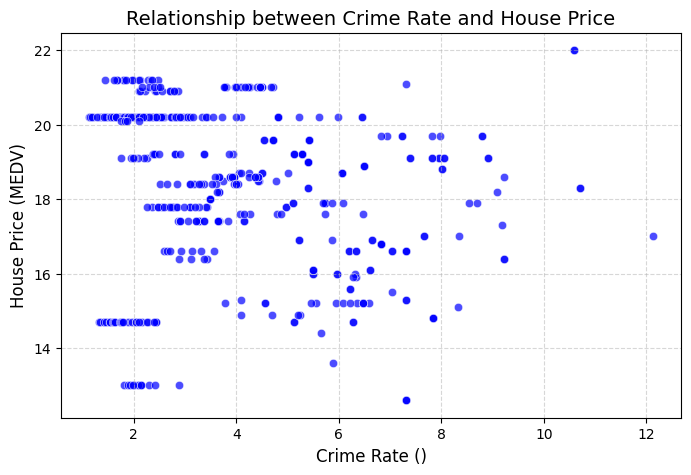

In [8]:
# df_boston["CRIM"].value_counts()

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="DIS", 
    y="PTRATIO", 
    data=df_boston, 
    alpha=0.7,      
    color="blue"    
)

plt.title("Relationship between Crime Rate and House Price", fontsize=14)
plt.xlabel("Crime Rate ()", fontsize=12)
plt.ylabel("House Price (MEDV)", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

빈도수
CHAS
0.0    471
1.0     35
Name: count, dtype: int64

비율(%)
CHAS
0.0    93.08
1.0     6.92
Name: proportion, dtype: float64


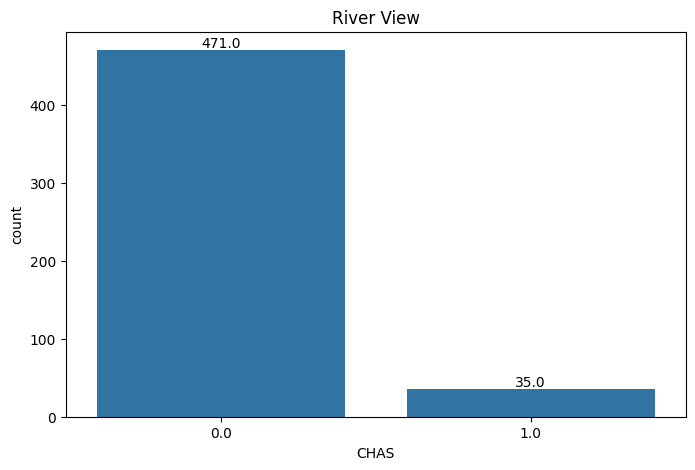

In [9]:
# 강세권 영향 확인
count = (df_boston["CHAS"].value_counts())

print("빈도수")
print(count)

print()

# 비율
ratio = (df_boston["CHAS"].value_counts(normalize=True)*100)

print("비율(%)")
print(ratio.round(2))

# 시각화
plt.figure(
    figsize=(8,5)
)


ax = sns.countplot(
    x="CHAS",
    data=df_boston
)

# 막대 위 수치 출력
for p in ax.patches:
    height = p.get_height()
    
    ax.annotate(
        f"{height}",
        (
            p.get_x()
            +
            p.get_width()/2,
            height
            ),
        ha="center",
        va="bottom"
    )


plt.title(
    "River View"
)

plt.show()

# 0 => 강세권(X)
# 1 => 강세권

C:\Users\user\AppData\Local\Temp\ipykernel_8740\991211053.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\user\AppData\Roaming\Python\Python312\site-packages\IPython\core

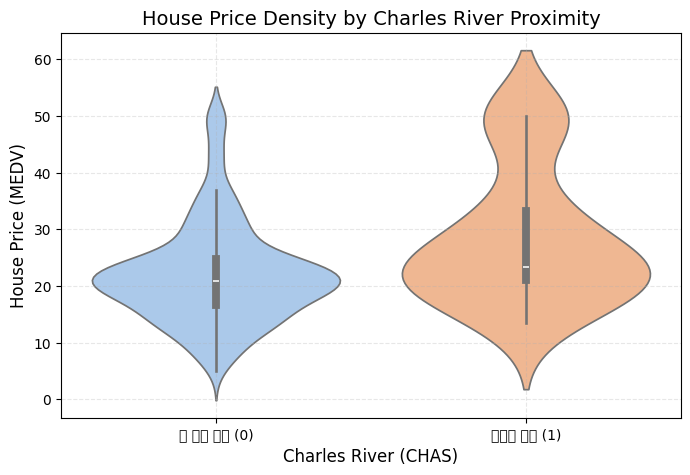

In [10]:
# 강세권과 주택 가격은 연관성이 있는 가?

plt.figure(figsize=(8, 5))

# sns.violinplot으로 데이터의 부피(밀도)까지 시각화
sns.violinplot(
    x="CHAS", 
    y="MEDV", 
    data=df_boston,
    palette="pastel"
)

plt.xticks([0, 1], ['강 주변 아님 (0)', '찰스강 주변 (1)'])
plt.title("House Price Density by Charles River Proximity", fontsize=14)
plt.xlabel("Charles River (CHAS)", fontsize=12)
plt.ylabel("House Price (MEDV)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

# 분석

# 찰스 강 주변의 위치(강세권)가 그렇지 않은 위치보다 전체적으로 위쪽으로 치우쳐있다.
# 찰스 강 조망 여부는 주택 가격 상승에 유의미한 영향(긍정적)을 미친다고 볼 수 있다.

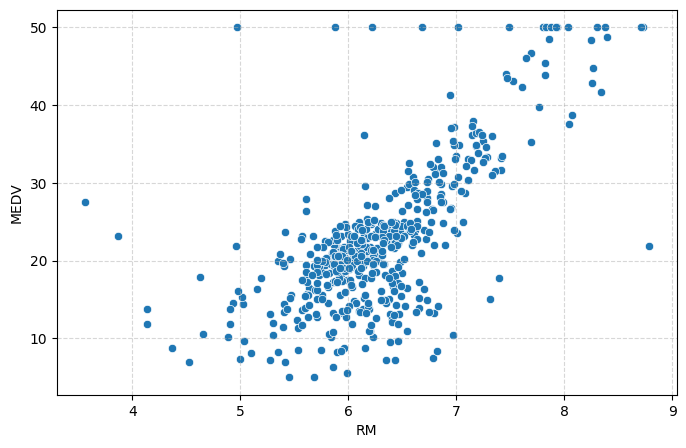

In [15]:
# 방 개수 와 주택 가격은 연관성이 있는가?

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="RM",
    y="MEDV",
    data=df_boston
    )

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

# 분석

# 산점도가 우상향 곡선을 그리고 있다.
# 방 개수가 6개인 쪽에 밀집된 것으로 보아 대중적으로 선호하는 방 개수는 6개라 볼 수 있다. 